<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>
<h4 style="color: #CEDDF4;" > 2.4: ML for Stock Market Prices depending on gold and oil models</h4>

In this section, we aim to forecast major stock market prices over a specified timeframe. For the scope of this academic exercise, the prediction window is set from **January 1, 2026, to April 30, 2026**. 

But, unlike what happened previously in section 2.3, we'll use the developed models in sections 2.1 and 2.2 as an input for this models.

To evaluate performance, we will implement and compare two distinct modeling approaches:

*   **Top Features Model:** This approach utilizes a curated subset of variables identified as having the most significant impact on each individual stock market prices. The exact number of features retained is an adjustable hyperparameter that can be optimized during the model's fine-tuning phase.
*   **Full Feature Model:** This baseline approach incorporates all available features within the dataset to generate predictions.

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [2]:
import os
import math
from pathlib import Path
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb
import joblib
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import matplotlib.ticker as mticker

In [3]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >2. Data Reading and Processing</h4>

In [4]:
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

<h4 style="color: #CEDDF4;" >2.1 Handling data </h4>

In [5]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
data = df[df['date'] <= '2025-08-30']
data_clean = data.copy()

for col in data_clean.columns:
    if data_clean[col].dtype == "object":
        data_clean[col] = data_clean[col].astype(str).str.replace('%', '', regex=False)
        data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
data_clean = data_clean.apply(pd.to_numeric, errors='coerce')
data_clean = data_clean.dropna(axis=1, how='all')

<h4 style="color: #CEDDF4;">3. Stock Market Prediction Loop — Setup</h4>

<h4 style="color: #CEDDF4;"> 3.1 Market Registry</h4>

In [6]:
# each entry: (display_name, target_col, currency, accent_hex, fill_hex)
STOCK_MARKETS = [
    ('NASDAQ',        'nasdaq_price_usd',            'USD', '#0057B8', '#CCE0F5'),
    ('S&P 500',       'sp500_price_usd',             'USD', '#006644', '#CCF0E0'),
    ('Dow Jones',     'dowjones_price_usd',          'USD', '#7B2D8B', '#EFD9F7'),
    ('Shanghai',      'china_shanghai_price_usd',    'USD', '#C0392B', '#F9D6D3'),
    ('Hong Kong',     'hongkong_hongkong_price_usd', 'USD', '#E67E22', '#FDEBD0'),
    ('London',        'uk_london_price_usd',         'USD', '#2C3E50', '#D5D8DC'),
    ('Tokyo',         'japan_tokyo_price_usd',       'USD', '#8B1A1A', '#FADBD8'),
    ('Egypt (EGX30)', 'egx30_price_egp',             'EGP', '#006B3C', '#D5F5E3'),
]

# complete list of all stock market columns — used to wipe cross-market leakage
ALL_STOCK_COLS = ['china_shanghai_price_usd', 'china_shanghai_high_usd', 'china_shanghai_low_usd', 'china_shanghai_open_usd', 'egx30_price_egp', 'egx30_high_price_egp', 'egx30_low_price_egp', 'egx30_change_percent', 'hongkong_hongkong_price_usd', 'hongkong_hongkong_high_usd', 'hongkong_hongkong_low_usd', 'hongkong_hongkong_open_usd', 'japan_tokyo_price_usd', 'japan_tokyo_high_usd', 'japan_tokyo_low_usd', 'japan_tokyo_open_usd', 'uk_london_price_usd', 'uk_london_high_usd', 'uk_london_low_usd', 'uk_london_open_usd', 'dowjones_price_usd', 'dowjones_high_usd', 'dowjones_low_usd', 'dowjones_open_usd', 'nasdaq_price_usd', 'nasdaq_high_usd', 'nasdaq_low_usd', 'nasdaq_open_usd', 'sp500_price_usd', 'sp500_high_usd', 'sp500_low_usd', 'sp500_open_usd']

<h4 style="color: #CEDDF4;"> 3.2 Load Saved Oil and Gold Models</h4>

In [7]:
with open(ai_data_dir / 'models'/'standalone_oil_price_top_model.pkl',          'rb') as f:
    oil_top_model = pickle.load(f)

with open(ai_data_dir / 'models'/ 'standalone_oil_price_full_model.pkl',         'rb') as f:
    oil_full_model = pickle.load(f)

with open(ai_data_dir / 'models'/'standalone_gold_price_top_features_model.pkl',         'rb') as f:
    gold_top_model = pickle.load(f)

with open(ai_data_dir / 'models'/ 'standalone_gold_price_full_model.pkl','rb') as f:
    gold_full_model = pickle.load(f)


<h4 style="color: #CEDDF4;"> 3.3 Reconstruct Oil and Gold Feature Tables for Inference</h4>

In [8]:
# ── helper: replicate gold/oil FE pipeline then align to model's exact feature list ──
def build_commodity_features(df_raw, target_col, top_model):
    """
    Builds the same features the gold/oil model was trained on.
    Strategy:
      1. Run the full FE pipeline (same as original gold/oil notebook).
      2. Get the model's authoritative feature list via feature_name_.
      3. Add any missing columns as 0 (rare edge-case for cols that existed
         in training data but were raw columns not present in master_table).
      4. Return the DataFrame with columns in the exact model order.
    """
    d = df_raw.copy()
    d['date'] = pd.to_datetime(d['date'], dayfirst=False, format='mixed', errors='coerce')
    d = d.sort_values('date').reset_index(drop=True)

    # strip % signs from object columns
    for col in d.columns:
        if d[col].dtype == 'object':
            d[col] = d[col].astype(str).str.replace('%', '', regex=False)
            d[col] = pd.to_numeric(d[col], errors='coerce')

    # ── leakage drop — mirrors original gold/oil notebook cell 3.3 exactly ────
    leakage_kw = [
        '_open_', '_high_', '_low_',
        'gpr_event',
        'ai_gpr_Unnamed',
        'gold_price_oz_egp',
        'cbe_inflations_headline_inflation_yy',
        'cbe_inflations_core_inflation_yy',
    ]
    # for gold model: also drop gold_price_usd from raw cols
    # for oil model: keep gold_price_usd as a feature
    # We do NOT add target_col to leakage_kw — it is the target
    d = d.drop(columns=[
        c for c in d.columns if any(k in c for k in leakage_kw)
    ], errors='ignore')

    # ── macro FE — mirrors original cell 3.4 ──────────────────────────────────
    d['real_rate_us'] = d['usd_fedfunds_value'] - d['cpi_value']
    d['real_rate_eu'] = d['euro_interest_value'] - d['euro_inflation_value']
    d['oil_x_dxy']   = d['brent_oil_price_usd'] * d['dollarindex_value']
    d['vix_x_dxy']   = d['vix_price_usd']       * d['dollarindex_value']
    if 'sp500_price_usd' in d.columns:
        d['sp500_mom'] = d['sp500_price_usd'].pct_change()

    # ── price FE — mirrors original cell 3.5 ──────────────────────────────────
    d['log_price'] = np.log(d[target_col])
    d['return']    = d['log_price'].diff()
    d['target']    = d['return'].rolling(5).mean().shift(-1).clip(-0.03, 0.03)

    # ── lag features — mirrors original cell 3.6 ──────────────────────────────
    for lag in [1, 2, 3, 5, 10, 20]:
        d[f'return_lag_{lag}'] = d['return'].shift(lag)
    d['log_price_lag1'] = d['log_price'].shift(1)

    # ── vol & momentum — mirrors original cell 3.7 ────────────────────────────
    d['vol_7']         = d['return'].rolling(7).std().shift(1)
    d['vol_20']        = d['return'].rolling(20).std().shift(1)
    d['mom_7']         = d['return'].rolling(7).mean().shift(1)
    d['price_trend_7'] = d[target_col].rolling(7).mean().shift(1)

    d = d.dropna()

    # ── align to model's exact feature list ──────────────────────────────────
    model_features = top_model.feature_name_  # authoritative ordered list

    for col in model_features:
        if col not in d.columns:
            print(f"  [WARNING] Feature '{col}' missing from rebuilt table — filling with 0")
            d[col] = 0  # safe fallback; model will use low importance for it

    return d[['date', target_col] + list(model_features)], list(model_features)


# ── Build inference tables for gold and oil ───────────────────────────────────
df_raw_full = pd.read_csv(ai_data_dir / 'new_master_table.csv')

df_gold_inf, gold_feats = build_commodity_features(df_raw_full, 'gold_price_usd',      gold_top_model)
df_oil_inf,  oil_feats  = build_commodity_features(df_raw_full, 'brent_oil_price_usd', oil_top_model)

print(f"Gold inference table: {len(df_gold_inf)} rows, {len(gold_feats)} features (model expects {gold_top_model.n_features_in_})")
print(f"Oil  inference table: {len(df_oil_inf)} rows,  {len(oil_feats)} features (model expects {oil_top_model.n_features_in_})")
assert len(gold_feats) == gold_top_model.n_features_in_, "Gold feature count mismatch!"
assert len(oil_feats)  == oil_top_model.n_features_in_,  "Oil  feature count mismatch!"

  [WARNING] Feature 'opec_pressure' missing from rebuilt table — filling with 0
  [WARNING] Feature 'oil_vol_x_vix' missing from rebuilt table — filling with 0
Gold inference table: 3751 rows, 15 features (model expects 15)
Oil  inference table: 3751 rows,  20 features (model expects 20)


<h4 style="color: #CEDDF4;"> 4.4 Generate Predicted Gold and Oil Prices (Test Window)</h4>

In [9]:
TEST_START = '2026-01-01'
TEST_END   = '2026-04-30'

def predicted_price_series(df_inf, feats, target_col, top_model, test_start, test_end):
    """
    Returns a date-indexed Series of PREDICTED prices over the test window,
    chained from the last training price using the saved model.
    """
    train_part = df_inf[df_inf['date'] <= '2025-12-31']
    test_part  = df_inf[(df_inf['date'] > test_start) & (df_inf['date'] <= test_end)]

    start_price = train_part[target_col].iloc[-1]
    pred_returns = top_model.predict(test_part[feats])

    prices = [start_price]
    for r in pred_returns:
        prices.append(prices[-1] * np.exp(r))
    prices = prices[1:]

    return pd.Series(prices, index=test_part['date'].values, name=f'pred_{target_col}')


gold_pred_series = predicted_price_series(
    df_gold_inf, gold_feats, 'gold_price_usd', gold_top_model, TEST_START, TEST_END
)
oil_pred_series = predicted_price_series(
    df_oil_inf, oil_feats, 'brent_oil_price_usd', oil_top_model, TEST_START, TEST_END
)


<h4 style="color: #CEDDF4;"> 4.5 Results Container</h4>

In [10]:
# will be populated by the loop — keyed by market display name
stock_results = {}

<h4 style="color: #CEDDF4;">5. Stock Market Prediction — Main Loop</h4>


  NASDAQ  (nasdaq_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

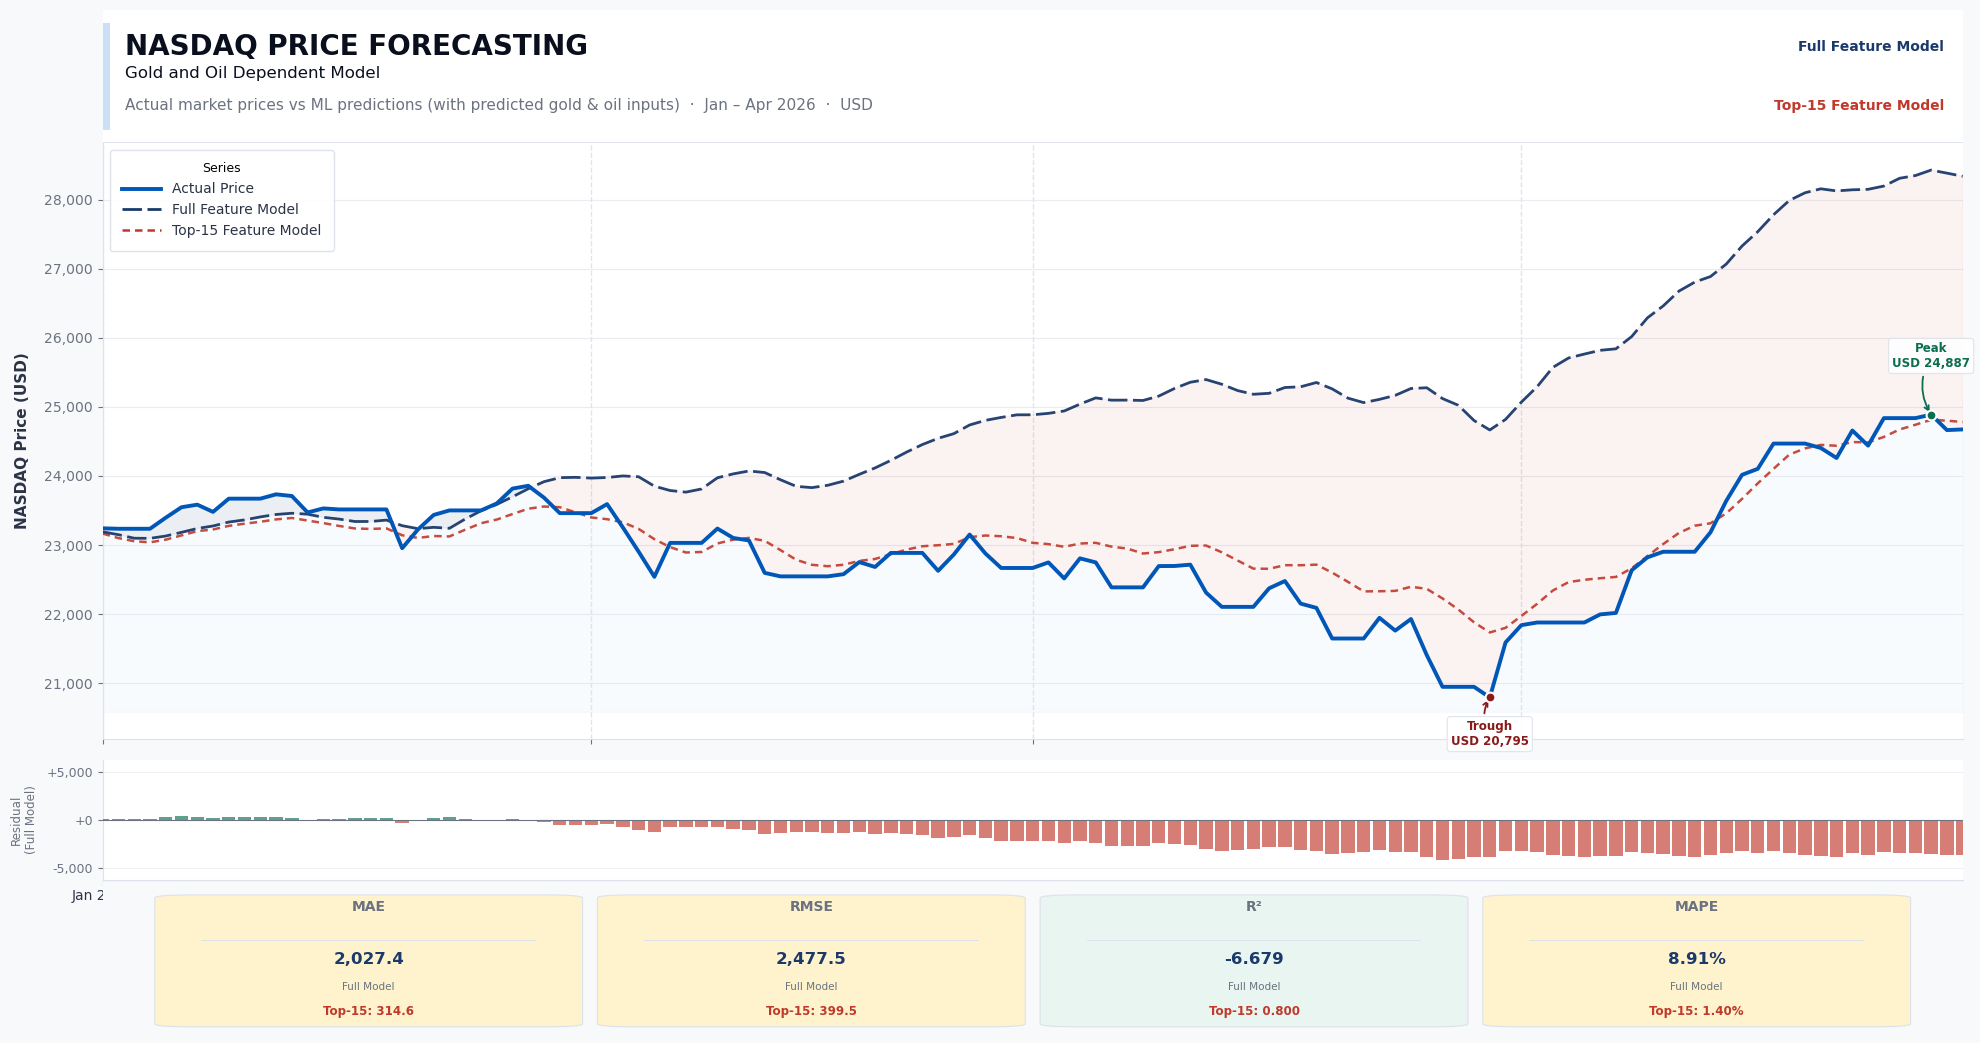

  Predicted NASDAQ Price Tomorrow: USD 23,224.05

  S&P 500  (sp500_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

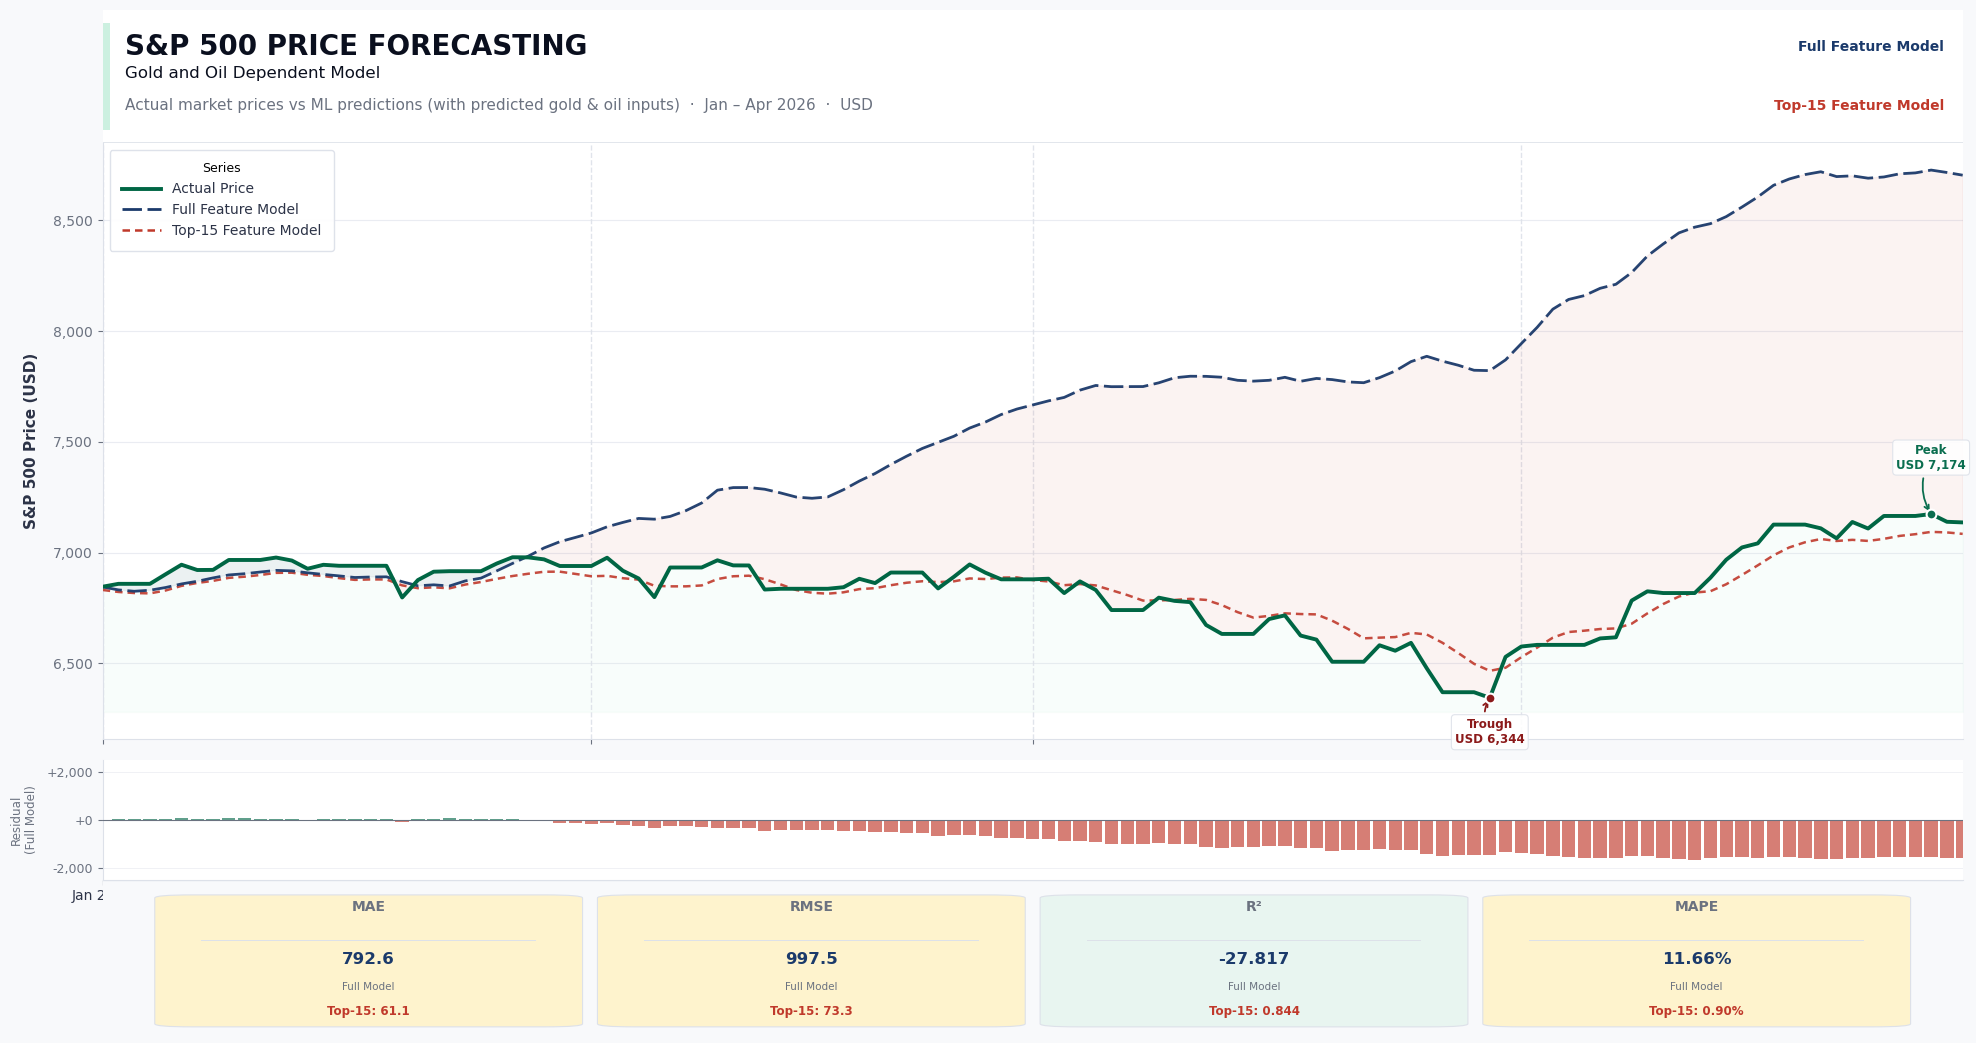

  Predicted S&P 500 Price Tomorrow: USD 6,839.16

  Dow Jones  (dowjones_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

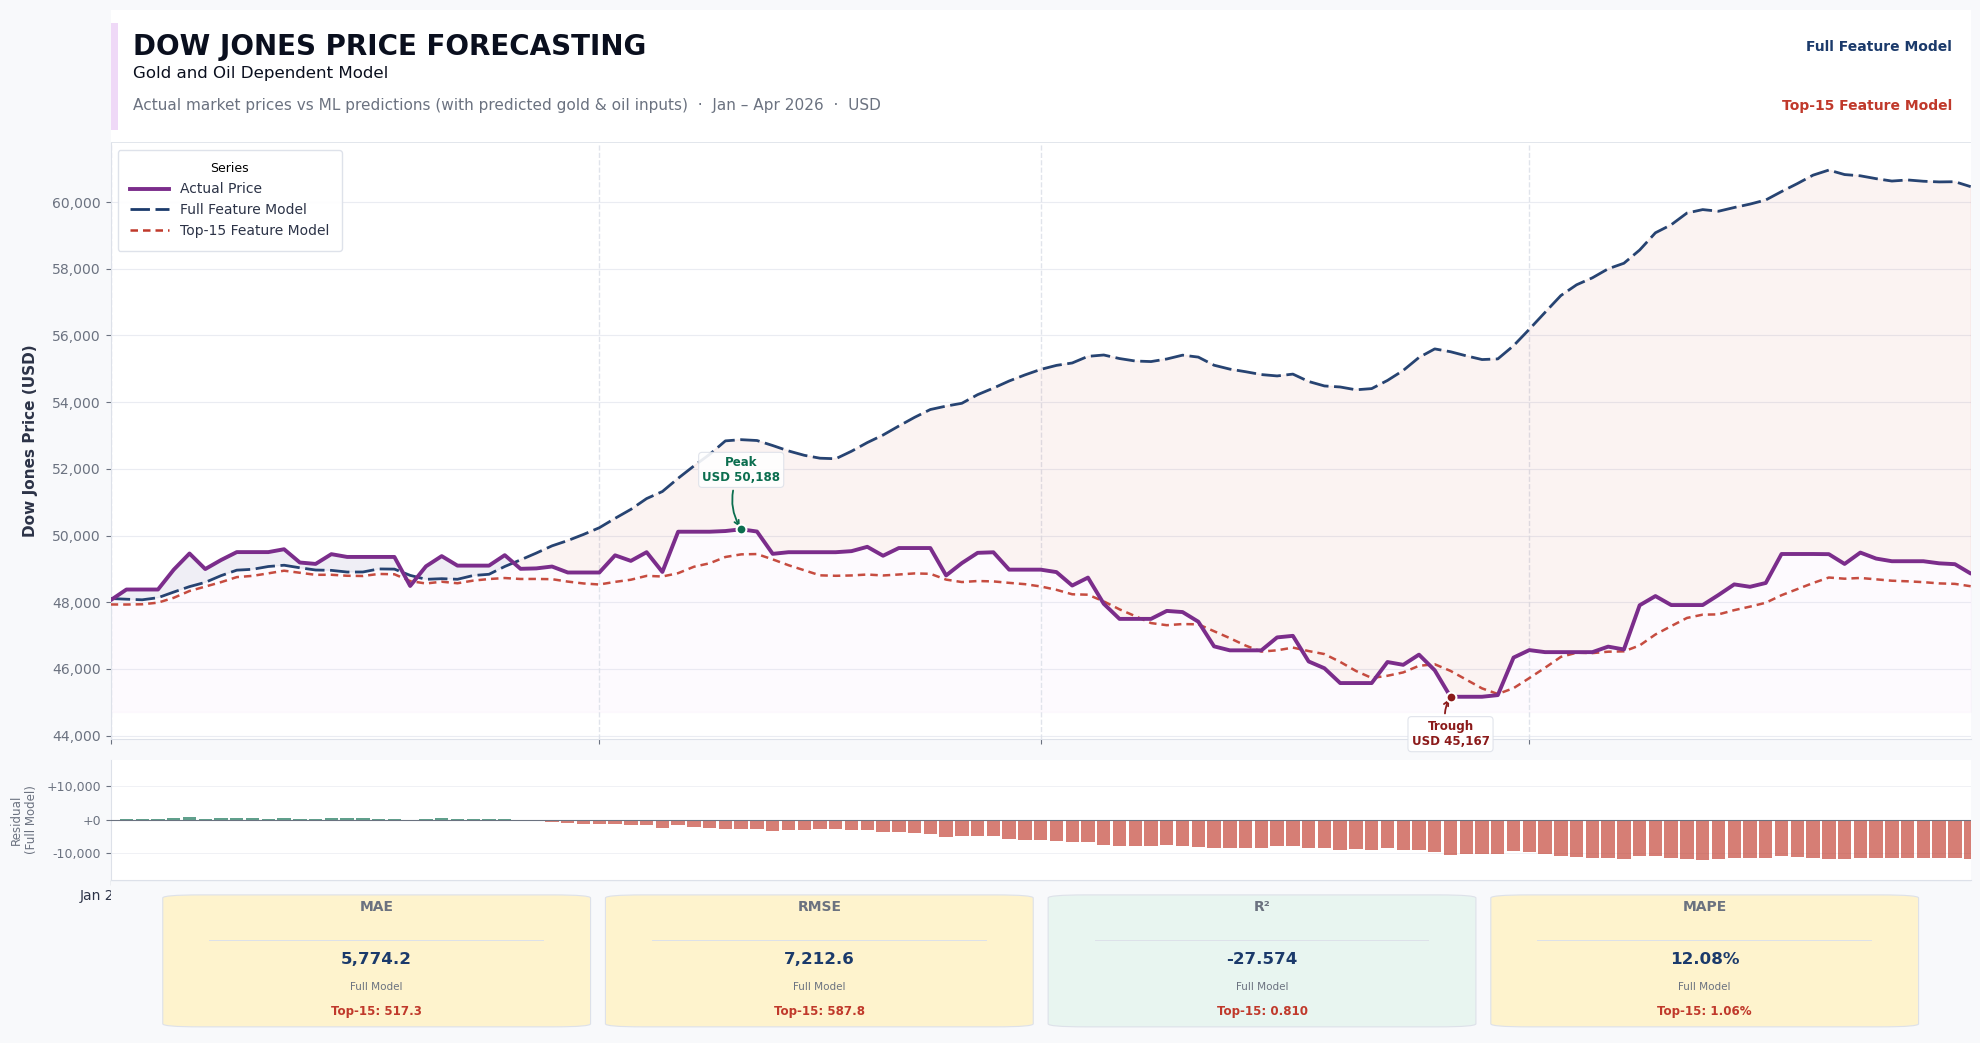

  Predicted Dow Jones Price Tomorrow: USD 47,992.95

  Shanghai  (china_shanghai_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

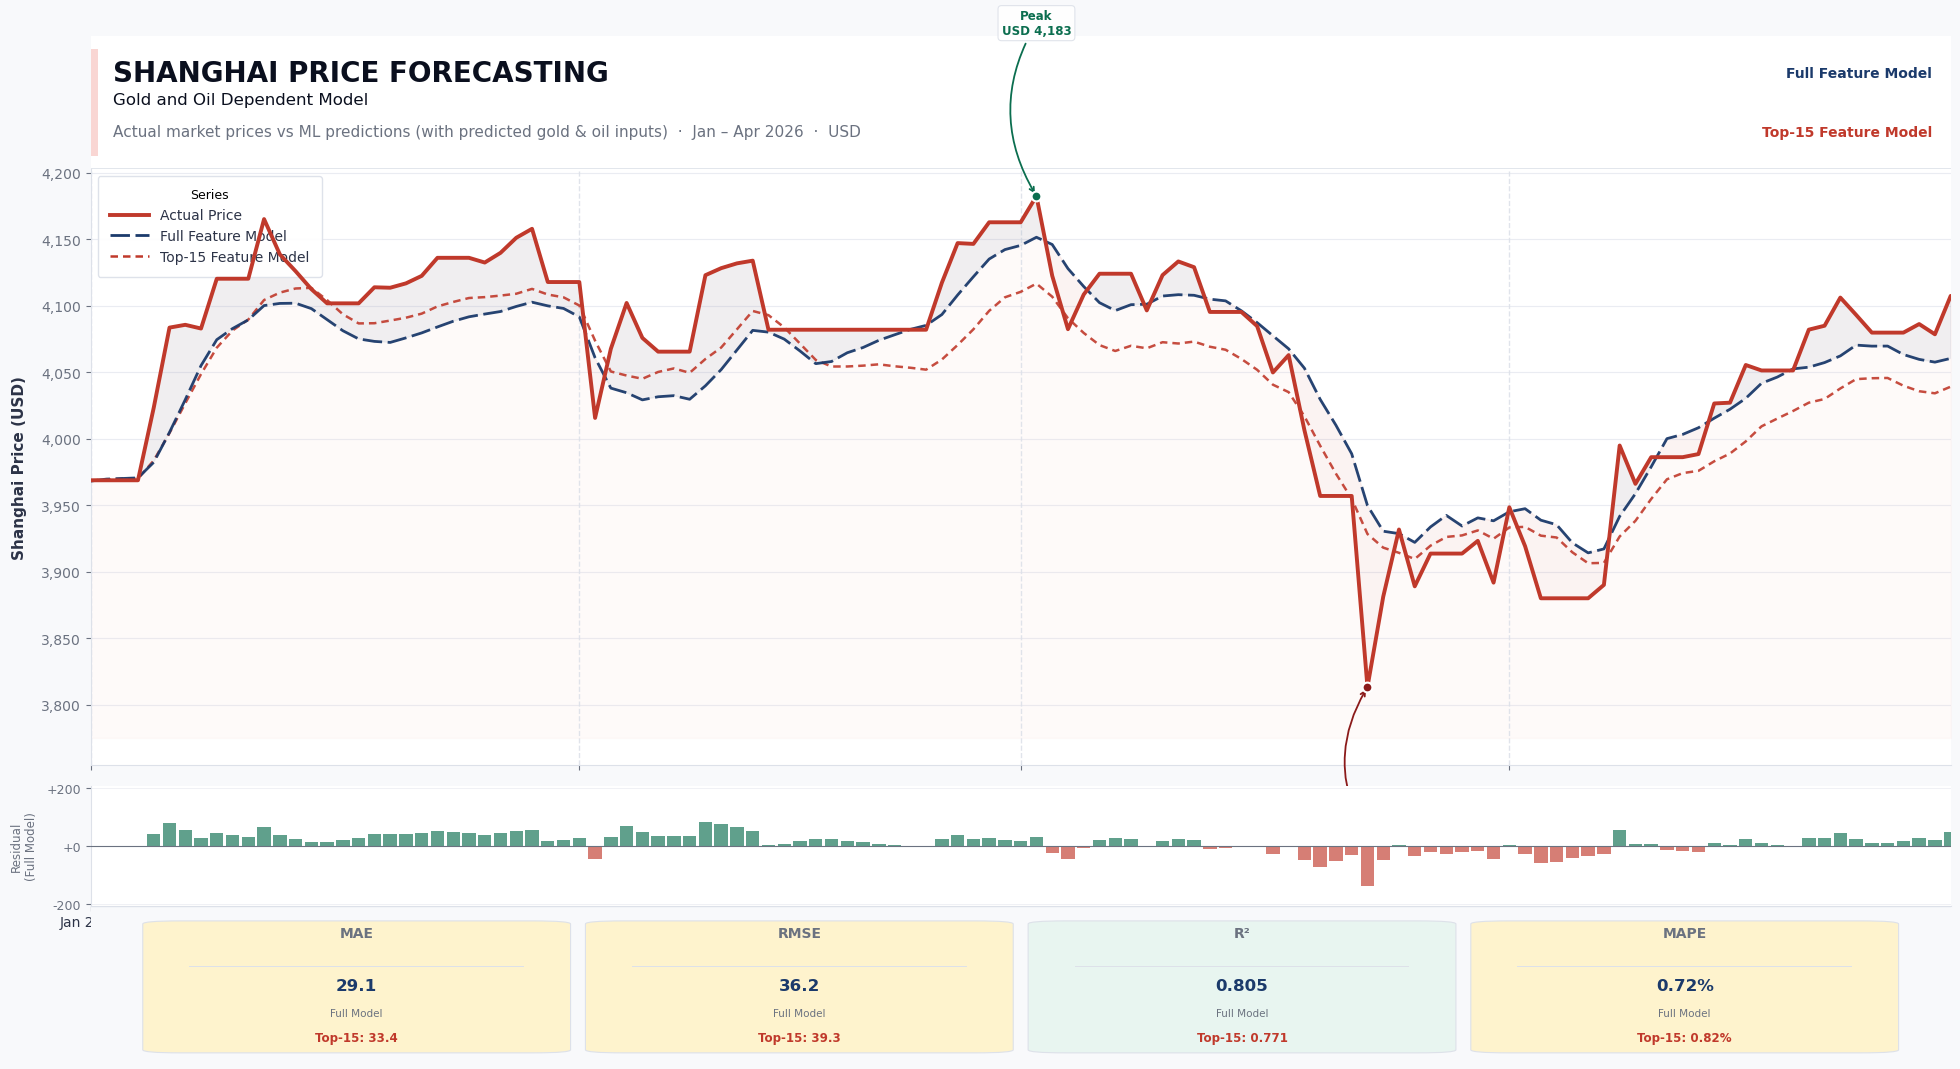

  Predicted Shanghai Price Tomorrow: USD 3,973.74

  Hong Kong  (hongkong_hongkong_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

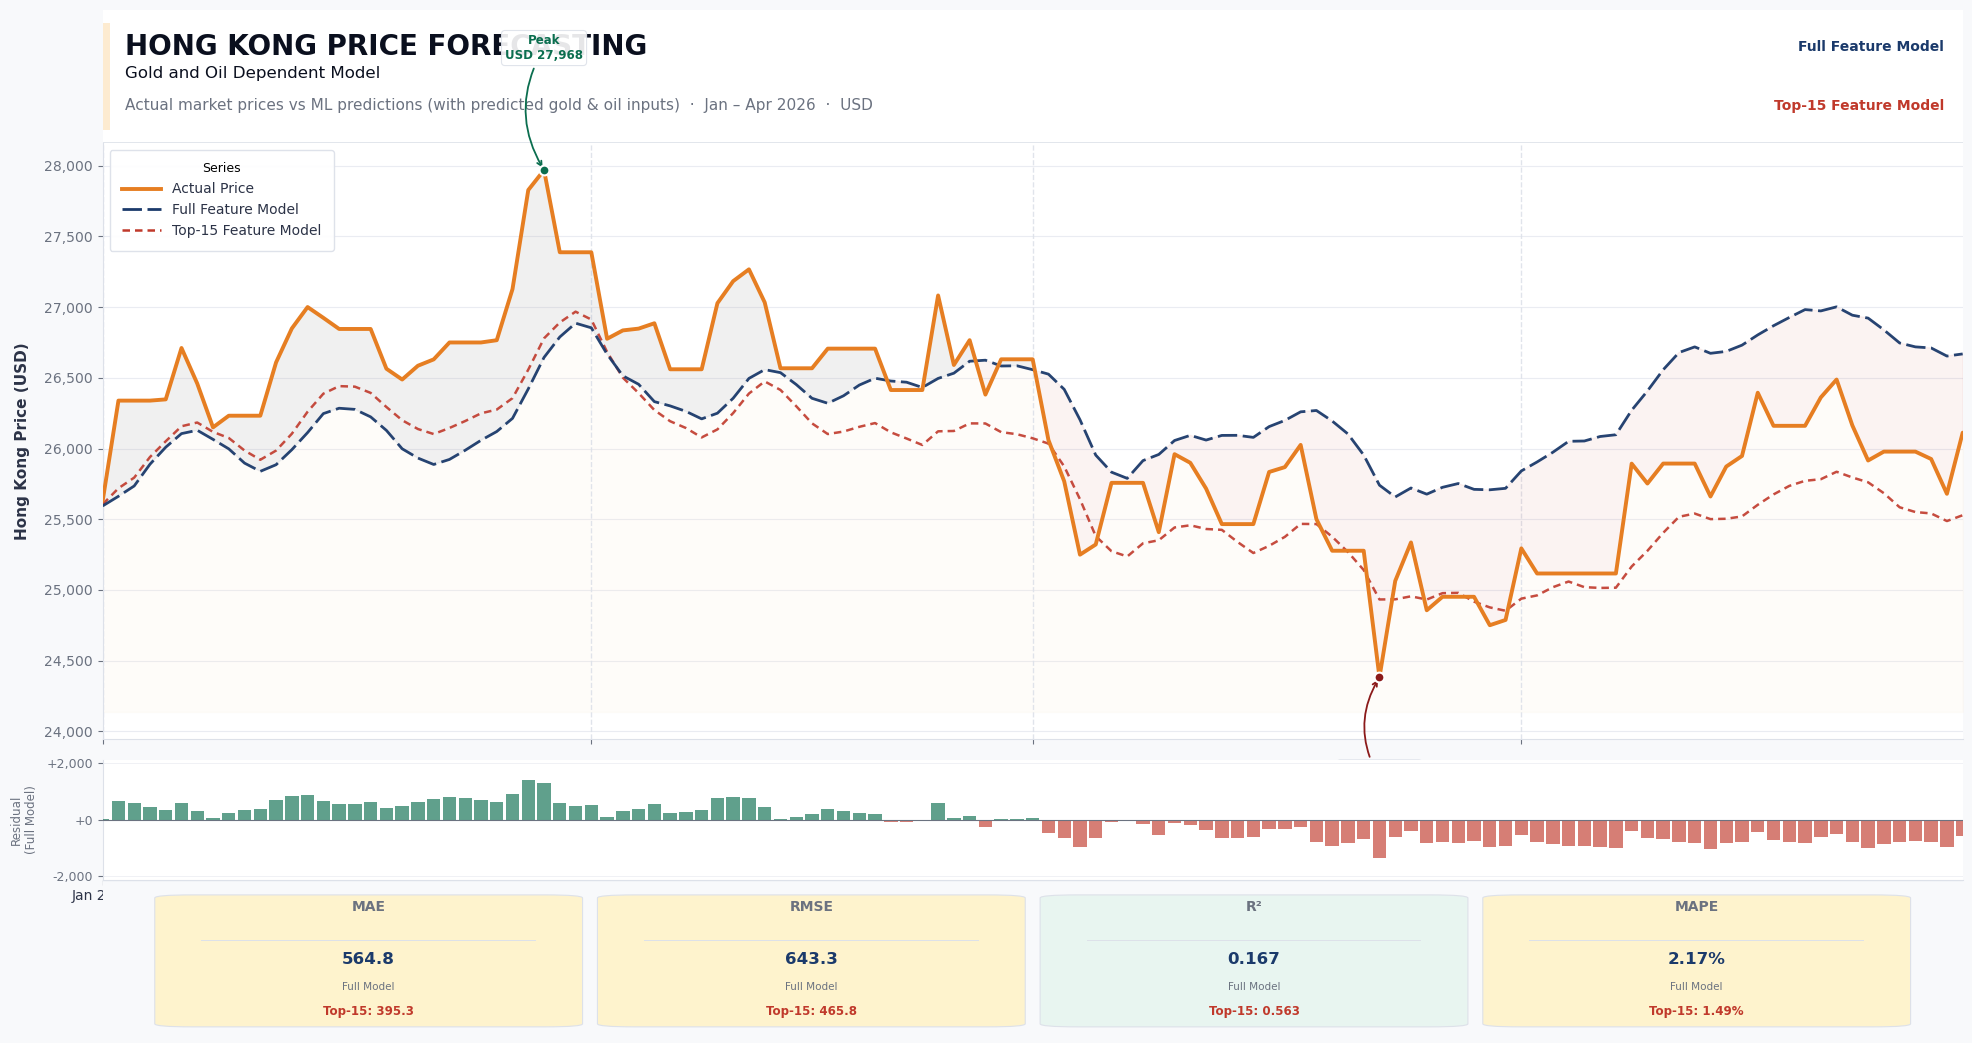

  Predicted Hong Kong Price Tomorrow: USD 25,671.89

  London  (uk_london_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

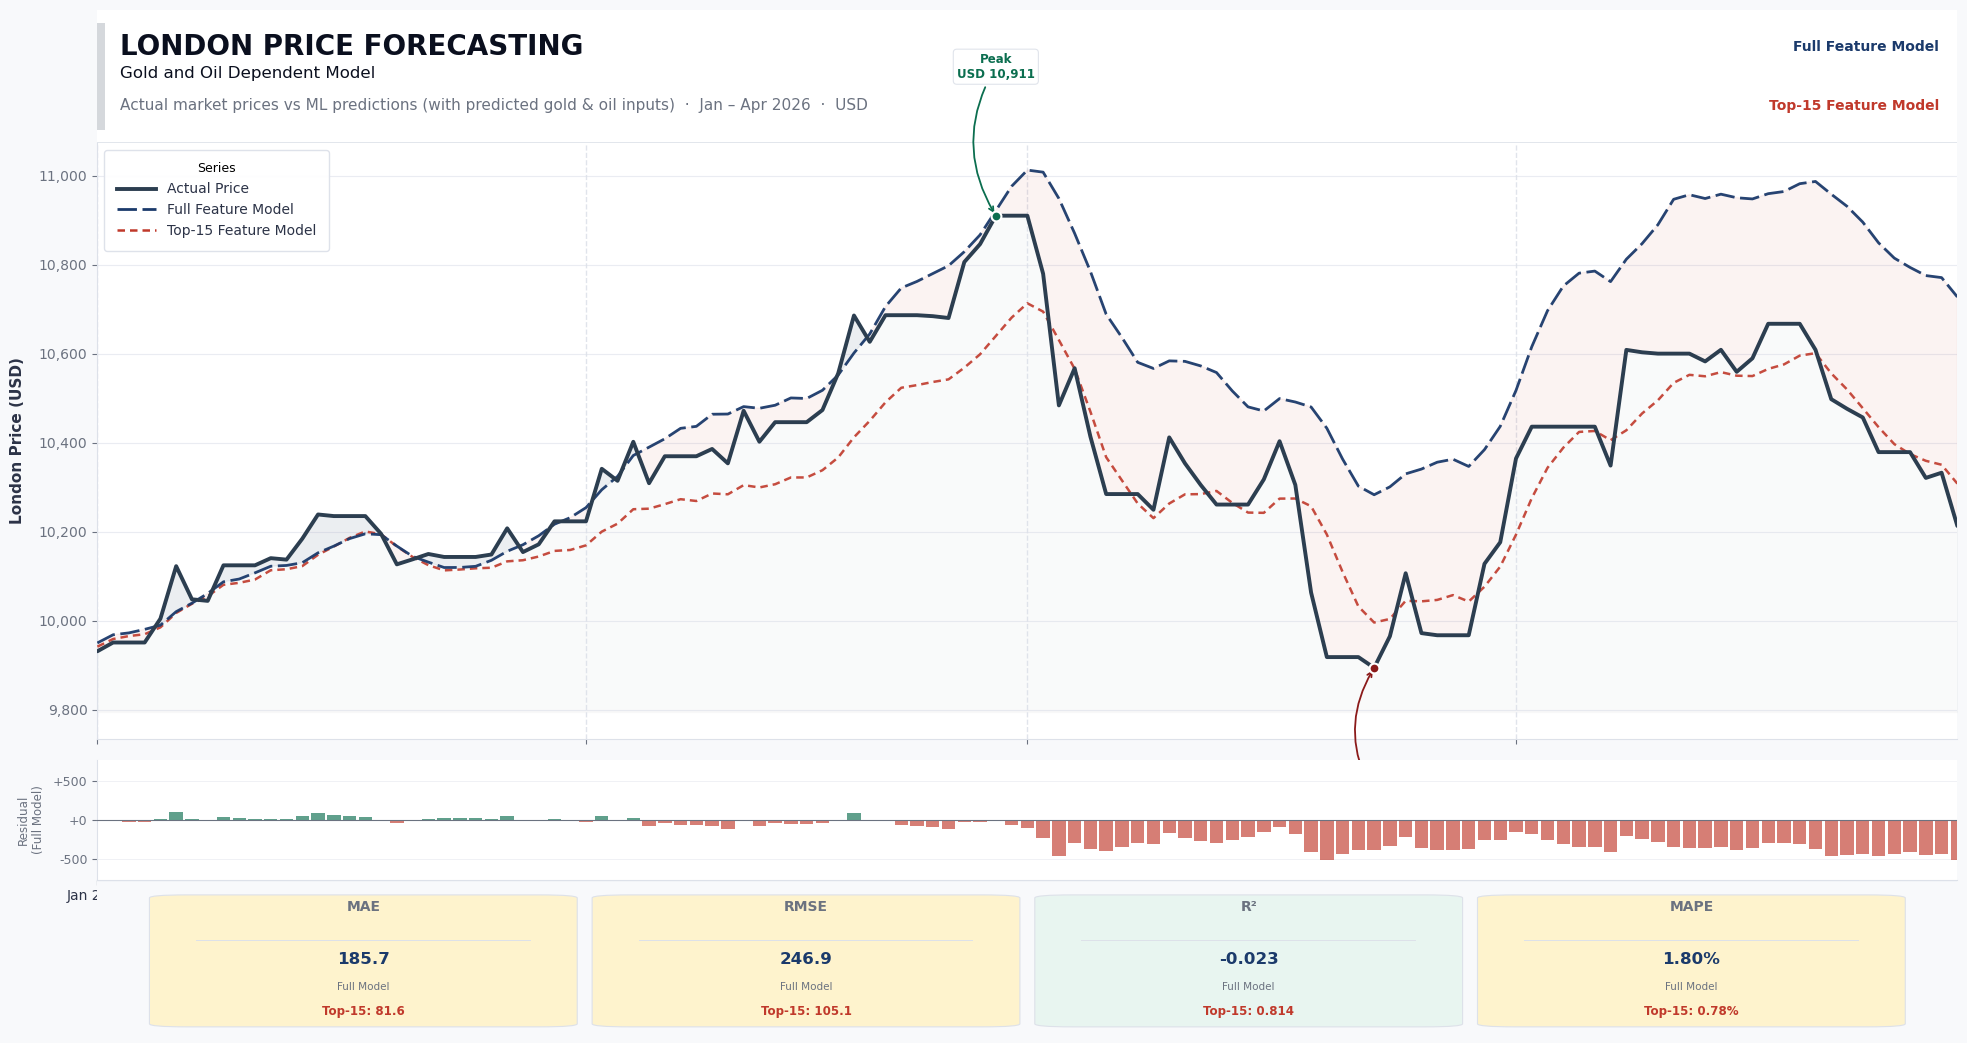

  Predicted London Price Tomorrow: USD 9,890.65

  Tokyo  (japan_tokyo_price_usd)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

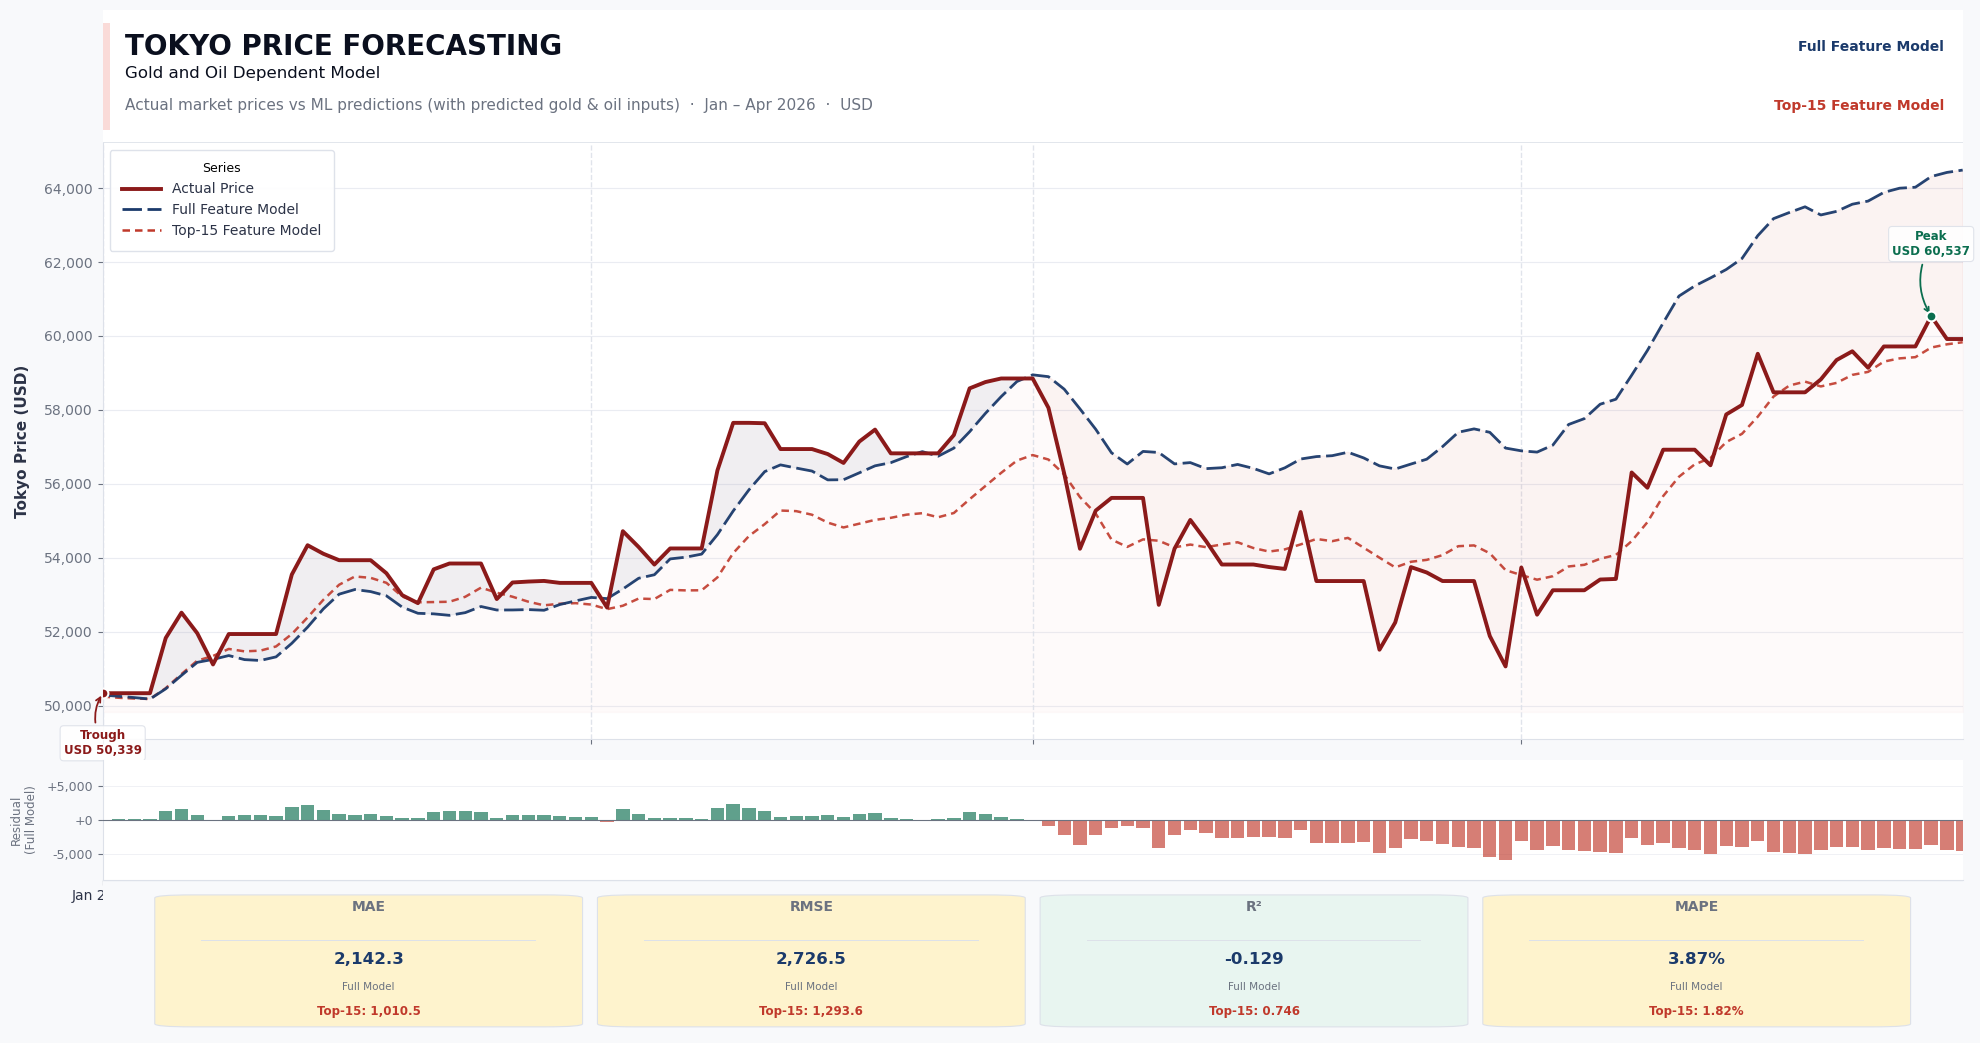

  Predicted Tokyo Price Tomorrow: USD 50,386.80

  Egypt (EGX30)  (egx30_price_egp)


C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dxy_lag1']       = df['dollarindex_value'].shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7']         = df['return'].rolling(7).std().shift(1)
C:\Users\HMSY\AppData\Local\Temp\ipykernel_392\2036383753.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

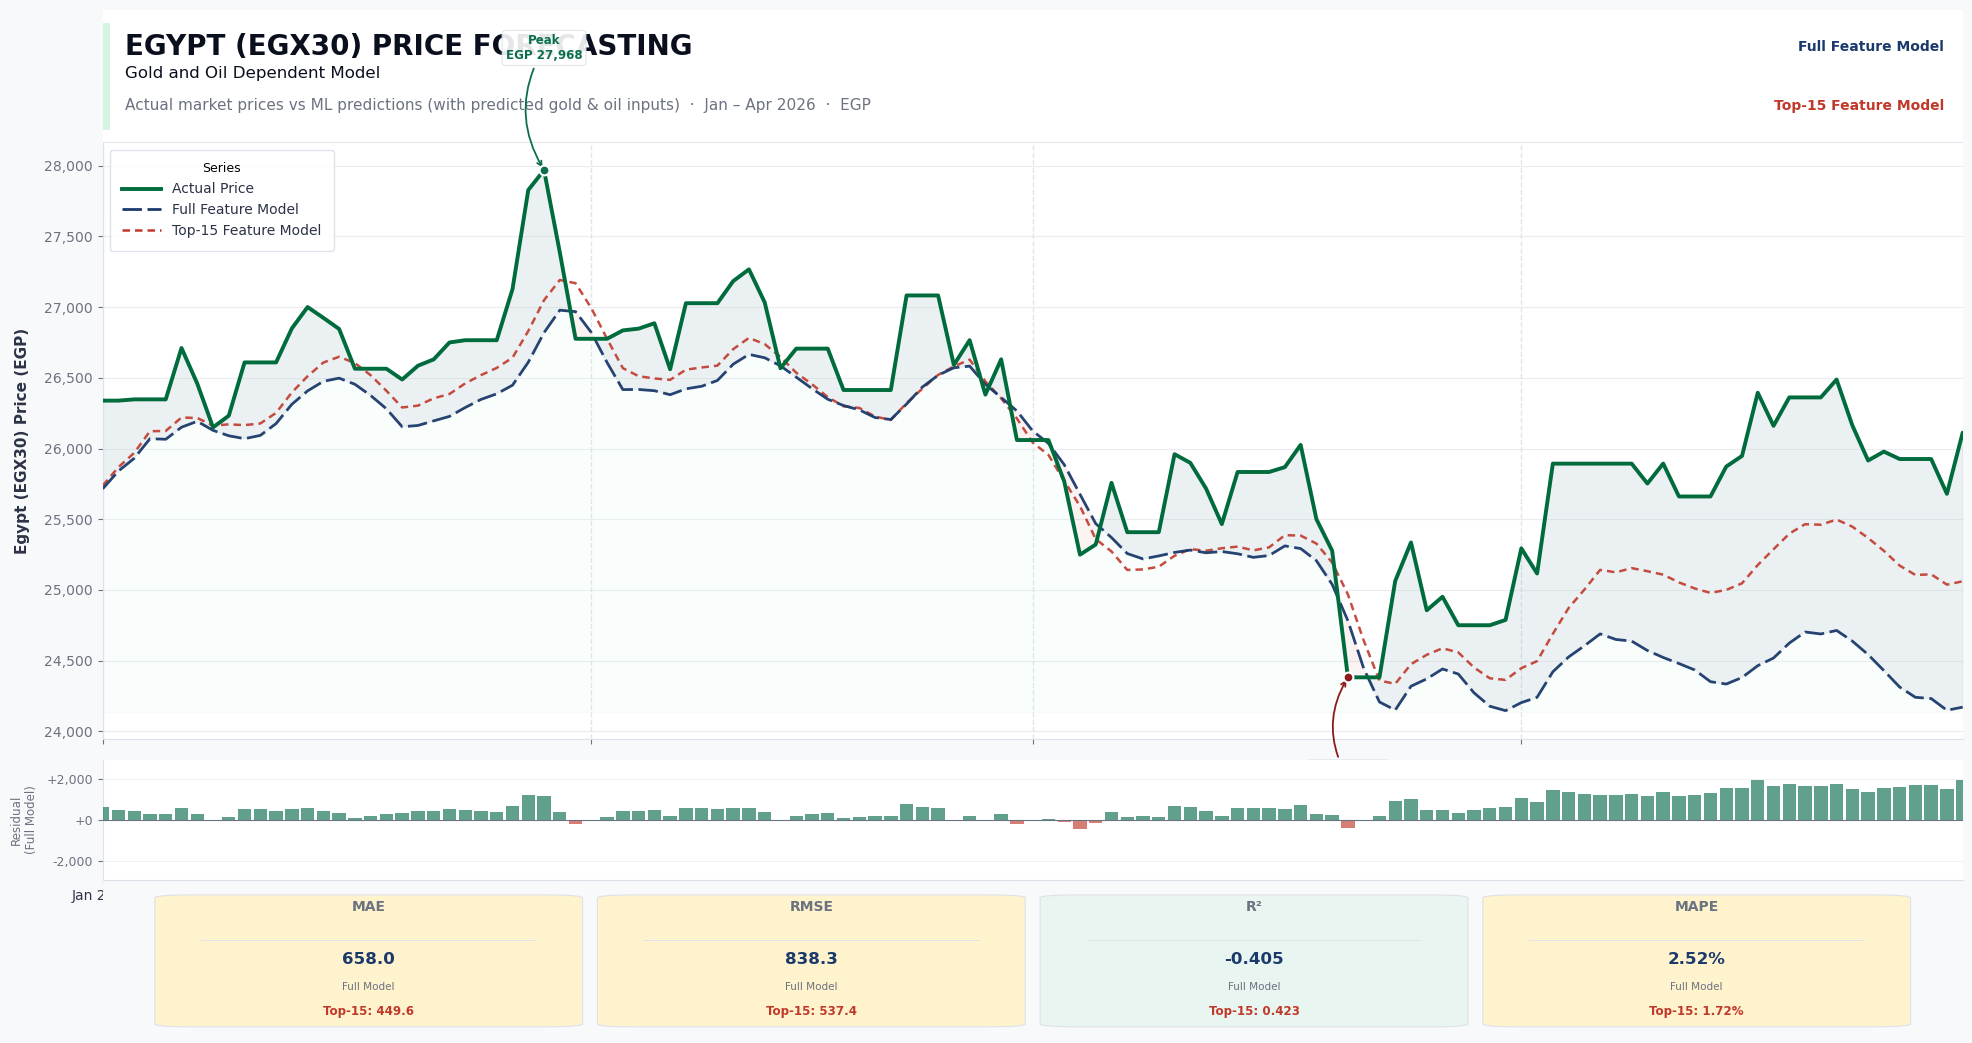

  Predicted Egypt (EGX30) Price Tomorrow: EGP 25,654.35


In [11]:
for (name, target_col, currency, accent, fill) in STOCK_MARKETS:

    print(f"\n{'='*65}")
    print(f"  {name}  ({target_col})")
    print(f"{'='*65}")

    # ── 5.1 Setup ────────────────────────────────────────────────────────────
    df = pd.read_csv(ai_data_dir / 'new_master_table.csv')


    # ── 5.2 Time preprocessing ───────────────────────────────────────────────
    df['date'] = pd.to_datetime(df['date'], dayfirst=False, format='mixed', errors='coerce')
    df = df.sort_values('date')


    # ── 5.3 Remove leakage features ──────────────────────────────────────────
    leakage_keywords = [
        '_open_', '_high_', '_low_',     # intraday OHLC on all assets
        '_open',  '_high',  '_low',      # suffix variants
        'gpr_event',                     # forward-looking flag
        'ai_gpr_Unnamed',                # index artefact
        'gold_price_oz_egp',             # EGP-denominated gold
        'cbe_inflations_headline_inflation_yy',
        'cbe_inflations_core_inflation_yy',
        '_energy_',                      # all country energy-mix columns
        'egpusd_value',                  # duplicated by FX cols
        'dollar_historical_data_value',  # duplicated by dollarindex_value
        'cpi_PCPIPCH',                   # duplicate CPI series
    ]
    df = df.drop(columns=[
        c for c in df.columns if any(k in c for k in leakage_keywords)
    ], errors='ignore')

    # drop all OTHER stock market columns (cross-market leakage)
    other_stock_cols = [c for c in ALL_STOCK_COLS if c != target_col and c in df.columns]
    df = df.drop(columns=other_stock_cols, errors='ignore')


    # ── 5.4 Macro feature engineering ────────────────────────────────────────
    df['real_rate_us']      = df['usd_fedfunds_value'] - df['cpi_value']
    df['real_rate_eu']      = df['euro_interest_value'] - df['euro_inflation_value']
    df['yield_spread_10_2'] = (
        df['10y_treasury_historical_data_monthly_value'] -
        df['2y_treasury_historical_data_monthly_value']
    )
    df['yield_spread_10_1'] = (
        df['10y_treasury_historical_data_monthly_value'] -
        df['1y_treasury_historical_data_monthly_value']
    )
    df['oil_x_dxy']  = df['brent_oil_price_usd'] * df['dollarindex_value']
    df['vix_x_dxy']  = df['vix_price_usd']       * df['dollarindex_value']
    df['gold_x_dxy'] = df['gold_price_usd']       * df['dollarindex_value']
    df['vix_mom']    = df['vix_price_usd'].pct_change()
    df['oil_mom']    = df['brent_oil_price_usd'].pct_change()
    df['gold_mom']   = df['gold_price_usd'].pct_change()


    # ── 5.5 Feature engineering ───────────────────────────────────────────────
    df['log_price'] = np.log(df[target_col])
    df['return']    = df['log_price'].diff()

    for w in [5, 10, 20, 50]:
        df[f'sma_{w}']          = df[target_col].rolling(w).mean().shift(1)
        df[f'price_vs_sma_{w}'] = (df[target_col] / df[f'sma_{w}'] - 1).shift(1)

    _delta    = df['return'].clip(lower=0)
    _loss     = (-df['return']).clip(lower=0)
    _avg_gain = _delta.rolling(14).mean()
    _avg_loss = _loss.rolling(14).mean().replace(0, 1e-9)
    df['rsi_14']   = (100 - 100 / (1 + _avg_gain / _avg_loss)).shift(1)

    _bb_mid        = df[target_col].rolling(20).mean()
    _bb_std        = df[target_col].rolling(20).std()
    df['bb_width'] = (4 * _bb_std / _bb_mid).shift(1)

    df['day_of_week']    = df['date'].dt.dayofweek
    df['month']          = df['date'].dt.month
    df['quarter']        = df['date'].dt.quarter
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
    df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)

    df['target'] = df['return'].rolling(5).mean().shift(-1)
    df['target'] = df['target'].clip(-0.03, 0.03)


    # ── 5.6 Lag features ──────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10, 20]:
        df[f'return_lag_{lag}'] = df['return'].shift(lag)
    df['log_price_lag1'] = df['log_price'].shift(1)
    df['vix_lag1']       = df['vix_price_usd'].shift(1)
    df['gold_lag1']      = df['gold_price_usd'].shift(1)
    df['oil_lag1']       = df['brent_oil_price_usd'].shift(1)
    df['dxy_lag1']       = df['dollarindex_value'].shift(1)


    # ── 5.7 Volatility and momentum ───────────────────────────────────────────
    df['vol_7']         = df['return'].rolling(7).std().shift(1)
    df['vol_20']        = df['return'].rolling(20).std().shift(1)
    df['vol_ratio']     = df['vol_7'] / (df['vol_20'] + 1e-9)
    df['mom_7']         = df['return'].rolling(7).mean().shift(1)
    df['mom_20']        = df['return'].rolling(20).mean().shift(1)
    df['mom_crossover'] = df['mom_7'] - df['mom_20']
    df['price_trend_7'] = df[target_col].rolling(7).mean().shift(1)
    df['price_trend_20']= df[target_col].rolling(20).mean().shift(1)


    # ── 5.8 Data cleaning ─────────────────────────────────────────────────────
    df = df.dropna()


    # ── 5.9 Feature selection ─────────────────────────────────────────────────
    features = [c for c in df.columns if c not in ['date', target_col, 'target']]


    # ── 5.10 Train/test split ─────────────────────────────────────────────────
    train = df[df['date'] <= '2025-12-31']
    test  = df[(df['date'] > '2025-12-31') & (df['date'] <= '2026-04-30')]

    X_train = train[features]
    y_train = train['target']
    X_test  = test[features]
    y_test  = test['target']


    # ── 5.10a Inject predicted gold & oil prices into the TEST features ───────
    # During training the model sees ACTUAL gold/oil prices.
    # During testing we replace gold_price_usd and brent_oil_price_usd
    # (and their derived features) with values predicted by the saved models,
    # so the pipeline does not rely on future actual commodity data.

    X_test = X_test.copy()

    # align prediction series to test index by date
    test_dates = test['date'].values

    for col_name, pred_series in [('gold_price_usd', gold_pred_series),
                                   ('brent_oil_price_usd', oil_pred_series)]:
        if col_name not in X_test.columns:
            continue
        pred_aligned = pd.Series(pred_series.values, index=pred_series.index)
        mapped = pd.Series(test_dates).map(
            dict(zip(pred_aligned.index, pred_aligned.values))
        ).values
        X_test[col_name] = mapped

    # rebuild interaction features that depend on gold/oil for test rows
    if 'gold_price_usd' in X_test.columns and 'dollarindex_value' in X_test.columns:
        X_test['gold_x_dxy'] = X_test['gold_price_usd'] * X_test['dollarindex_value']
        X_test['gold_lag1']  = X_test['gold_price_usd']          # lag1 ≈ same-day predicted
        X_test['gold_mom']   = X_test['gold_price_usd'].pct_change().fillna(0)

    if 'brent_oil_price_usd' in X_test.columns and 'dollarindex_value' in X_test.columns:
        X_test['oil_x_dxy'] = X_test['brent_oil_price_usd'] * X_test['dollarindex_value']
        X_test['oil_lag1']  = X_test['brent_oil_price_usd']
        X_test['oil_mom']   = X_test['brent_oil_price_usd'].pct_change().fillna(0)


    # ── 5.11 Time series cross-validation ─────────────────────────────────────
    tscv = TimeSeriesSplit(n_splits=5)

    for i, (tr, val) in enumerate(tscv.split(X_train)):
        model_cv = lgb.LGBMRegressor(
            n_estimators=2000,
            learning_rate=0.01,
            num_leaves=64,
            max_depth=6,
            verbose=-1
        )
        model_cv.fit(X_train.iloc[tr], y_train.iloc[tr])
        pred_cv = model_cv.predict(X_train.iloc[val])

    # ── 5.12 Full model training ──────────────────────────────────────────────
    model = lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)


    # ── 5.13 Feature selection ────────────────────────────────────────────────
    selector = SelectFromModel(model, threshold='median', prefit=True)

    X_train_sel = selector.transform(X_train)
    X_test_sel  = selector.transform(X_test)

    model.fit(X_train_sel, y_train)
    with open(ai_data_dir / 'models' / f'gold_and_oil_dependent_{name.replace(" ","_")}_full_model.pkl', 'wb') as f:
        pickle.dump(model, f)


    # ── 5.14 Prediction (full model) ─────────────────────────────────────────
    pred_returns = model.predict(X_test_sel)


    # ── 5.15 Price Prediction (full model) ───────────────────────────────────
    start_price = train[target_col].iloc[-1]

    prices = [start_price]
    for r in pred_returns:
        prices.append(prices[-1] * np.exp(r))
    prices = prices[1:]

    test = test.copy()
    test['pred_price'] = prices


    # ── 5.16 Evaluation (full model) ─────────────────────────────────────────
    mae       = mean_absolute_error(test[target_col], test['pred_price'])
    direction = np.mean(np.sign(test['target']) == np.sign(pred_returns))

    # ── 5.17 Top Features Extraction ─────────────────────────────────────────
    importance_model = lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    importance_model.fit(X_train, y_train)

    importance = pd.Series(
        importance_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)


    # ── 5.18 Top Features selection ───────────────────────────────────────────
    top_k        = 15
    top_features = importance.head(top_k).index.tolist()

    X_train_top = X_train[top_features]
    X_test_top  = X_test[top_features]


    # ── 5.19 Top model training ───────────────────────────────────────────────
    top_model = lgb.LGBMRegressor(
        objective='regression',
        boosting_type='gbdt',
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=128,
        max_depth=10,
        min_child_samples=10,
        min_child_weight=1e-3,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.3,
        random_state=42,
        verbose=-1
    )
    top_model.fit(X_train_top, y_train)

    with open(ai_data_dir / 'models' / f'gold_and_oil_dependent_{name.replace(" ","_")}_top_model.pkl', 'wb') as f:
        pickle.dump(top_model, f)

    pred_top = top_model.predict(X_test_top)


    # ── 5.20 Price Prediction (top model) ────────────────────────────────────
    prices_top = [start_price]
    for r in pred_top:
        prices_top.append(prices_top[-1] * np.exp(r))
    prices_top = prices_top[1:]
    test['pred_price_top'] = prices_top


    # ── 5.21 Evaluation (top model) ──────────────────────────────────────────
    mae_top       = mean_absolute_error(test[target_col], test['pred_price_top'])
    direction_top = np.mean(np.sign(test['target']) == np.sign(pred_top))

    # ── 5.22 Visualization ───────────────────────────────────────────────────
    def kpis(a, p):
        mae  = np.mean(np.abs(a - p))
        rmse = np.sqrt(np.mean((a - p) ** 2))
        r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
        mape = np.mean(np.abs((a - p) / a)) * 100
        return mae, rmse, r2, mape

    plot_df   = test.sort_values('date').copy()
    dates     = plot_df['date'].values
    actual    = plot_df[target_col].values
    full_pred = plot_df['pred_price'].values
    top_pred  = plot_df['pred_price_top'].values

    mae_f, rmse_f, r2_f, mape_f = kpis(actual, full_pred)
    mae_t, rmse_t, r2_t, mape_t = kpis(actual, top_pred)

    PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
    MKT_DARK  = accent
    MKT_FILL  = fill
    NAVY      = '#1B3A6B'
    CRIMSON   = '#C0392B'
    TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
    GREEN_KPI, GREEN_BG    = '#0B6E4F', '#E8F5F0'
    RED_KPI                = '#8B1A1A'
    AMBER_KPI, AMBER_BG    = '#7A4F00', '#FEF3CD'

    fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
    outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                              hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

    # header
    ax_head = fig.add_subplot(outer[0])
    ax_head.set_facecolor(WHITE)
    ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
    for sp in ax_head.spines.values(): sp.set_visible(False)
    ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
        boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
        transform=ax_head.transAxes, clip_on=False))
    ax_head.text(0.012, 0.72, f'{name.upper()} PRICE FORECASTING',
                 transform=ax_head.transAxes, fontsize=20, fontweight='bold', color=TEXT_H, va='center')
    ax_head.text(0.012, 0.52, 'Gold and Oil Dependent Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
    ax_head.text(0.012, 0.28,
        f'Actual market prices vs ML predictions (with predicted gold & oil inputs)  ·  Jan – Apr 2026  ·  {currency}',
        transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
    ax_head.text(0.99, 0.72, 'Full Feature Model',
                 transform=ax_head.transAxes, fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
    ax_head.text(0.99, 0.28, f'Top-{top_k} Feature Model',
                 transform=ax_head.transAxes, fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
    ax_head.axhline(0, color=BORDER, linewidth=1.2)

    # chart + residual
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                             height_ratios=[5, 1], hspace=0.06)
    ax   = fig.add_subplot(inner[0])
    ax_r = fig.add_subplot(inner[1], sharex=ax)

    for a in [ax, ax_r]:
        a.set_facecolor(WHITE)
        a.tick_params(colors=TEXT_M, labelsize=10)
        for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
        a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

    ax.fill_between(dates, actual, actual.min() - actual.min() * 0.01,
        color=MKT_FILL, alpha=0.12, zorder=1)
    ax.fill_between(dates, actual, full_pred,
        where=(actual >= full_pred), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
    ax.fill_between(dates, actual, full_pred,
        where=(actual < full_pred),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

    ax.plot(dates, actual,    color=MKT_DARK, linewidth=2.8, zorder=6,
            solid_capstyle='round', label='Actual Price')
    ax.plot(dates, full_pred, color=NAVY,     linewidth=2.0, linestyle=(0, (7, 2)),
            zorder=5, alpha=0.95, label='Full Feature Model')
    ax.plot(dates, top_pred,  color=CRIMSON,  linewidth=1.8, linestyle=(0, (3, 2)),
            zorder=4, alpha=0.90, label=f'Top-{top_k} Feature Model')

    for ms in pd.date_range(plot_df['date'].min(), plot_df['date'].max(), freq='MS'):
        ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
    ax.set_xlim(dates[0], dates[-1])

    pidx = np.argmax(actual); pval = actual[pidx]; pdate = dates[pidx]
    tidx = np.argmin(actual); tval = actual[tidx]; tdate = dates[tidx]
    offset = actual.mean() * 0.03
    for x, y, lbl, col, ya, arc in [
        (pdate, pval, f'Peak\n{currency} {pval:,.0f}',   GREEN_KPI, pval + offset,   0.3),
        (tdate, tval, f'Trough\n{currency} {tval:,.0f}', RED_KPI,   tval - offset,  -0.3),
    ]:
        ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
            fontsize=8.5, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=col,
                connectionstyle=f'arc3,rad={arc}', lw=1.3),
            bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
            zorder=10)
        ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylabel(f'{name} Price ({currency})', color=TEXT_B, fontsize=11,
                  fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelbottom=False)
    ax.legend(handles=[
        Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
        Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0, (7, 2)), label='Full Feature Model'),
        Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0, (3, 2)), label=f'Top-{top_k} Feature Model'),
    ], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
       labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
       title='Series', title_fontsize=9)

    res = actual - full_pred
    ax_r.bar(dates, res, color=[GREEN_KPI if v >= 0 else CRIMSON for v in res],
             alpha=0.65, width=0.85, zorder=3)
    ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
    ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
    ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
    ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
    ax_r.tick_params(colors=TEXT_M, labelsize=9)
    pad = max(abs(res.min()), abs(res.max())) * 1.5
    ax_r.set_ylim(-pad, pad)
    ax_r.xaxis.set_major_locator(mdates.MonthLocator())
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

    # KPI strip
    ax_kpi = fig.add_subplot(outer[2])
    ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
    for sp in ax_kpi.spines.values(): sp.set_visible(False)
    ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

    kpi_cards = [
        ('MAE',  f'{mae_f:,.1f}',  f'{mae_t:,.1f}',  AMBER_KPI, AMBER_BG),
        ('RMSE', f'{rmse_f:,.1f}', f'{rmse_t:,.1f}', AMBER_KPI, AMBER_BG),
        ('R²',   f'{r2_f:.3f}',    f'{r2_t:.3f}',    GREEN_KPI, GREEN_BG),
        ('MAPE', f'{mape_f:.2f}%', f'{mape_t:.2f}%', AMBER_KPI, AMBER_BG),
    ]
    card_w = 0.19
    gap    = (1.0 - len(kpi_cards) * card_w) / (len(kpi_cards) + 1)
    for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards):
        x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
        ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
            boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
            transform=ax_kpi.transAxes, clip_on=False))
        ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
            ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
        ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
            boxstyle='square,pad=0', fc=BORDER, ec='none',
            transform=ax_kpi.transAxes, clip_on=False))
        ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
            ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
        ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
            ha='center', va='center', fontsize=7.5, color=TEXT_M)
        ax_kpi.text(xc, 0.14, f'Top-{top_k}: {vt}', transform=ax_kpi.transAxes,
            ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

    safe = name.replace(' ', '_').replace('&', 'and').replace('(', '').replace(')', '')
    plt.savefig(ai_data_dir / 'visualizations'/f'{safe}_price_prediction_model.png',
                dpi=300, bbox_inches='tight', facecolor=PAGE)
    plt.show()

    # ── 5.23 Price Prediction (tomorrow) ─────────────────────────────────────
    latest_top = X_test_top.iloc[-1:]

    pred_return_tomorrow = top_model.predict(latest_top)[0]

    last_log_price = np.log(train[target_col].iloc[-1])

    pred_price_tomorrow = np.exp(last_log_price + pred_return_tomorrow)

    print(f"  Predicted {name} Price Tomorrow: {currency} {pred_price_tomorrow:,.2f}")

    # ── store results ─────────────────────────────────────────────────────────
    stock_results[name] = {
        'target_col':         target_col,
        'currency':           currency,
        'mae_full':           mae,
        'mae_top':            mae_top,
        'direction_full':     direction,
        'direction_top':      direction_top,
        'r2_full':            r2_f,
        'r2_top':             r2_t,
        'mape_full':          mape_f,
        'mape_top':           mape_t,
        'pred_price_tomorrow':pred_price_tomorrow,
        'top_features':       top_features,
    }

<h4 style="color: #CEDDF4;">6. Summary — All Markets</h4>

In [12]:
summary_rows = []
for mkt, r in stock_results.items():
    summary_rows.append({
        'Market':          mkt,
        'Currency':        r['currency'],
        'MAE (Top)':       round(r['mae_top'], 2),
        'MAPE (Top) %':    round(r['mape_top'], 2),
        'R² (Top)':        round(r['r2_top'], 4),
        'Dir (Top)':       round(r['direction_top'], 3),
        'MAE (Full)':      round(r['mae_full'], 2),
        'Dir (Full)':      round(r['direction_full'], 3),
        'Tomorrow':        round(r['pred_price_tomorrow'], 2),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Market')
summary_df.to_csv(ai_data_dir / 'oil_gold_dependent_stock_predictions_summary.csv')